# 프로젝트 관련 내용

| 번호 | 테이블명             | 테이블 설명                   | 주요 컬럼                                               |
|------|----------------------|-------------------------------|----------------------------------------------------------|
| 1    | trial_register       | 3일체험 신청                  | 유저id, 3일체험신청일시                                  |
| 2    | trial_visit_info     | 3일체험 신청자 일자별 방문기록 | 유저id, 날짜, 지점id, 최초입실시각, 최종퇴실시각, 체류시간 |
| 3    | trial_access_log     | 3일체험 신청자 출입기록        | 유저id, 지점id, timestamp, 출입방향                      |
| 4    | trial_payment        | 3일체험 신청자 결제 여부       | 유저id, 결제여부                                         |
| 5    | site_area            | 지점별 면적                   | 지점id, 지점 면적                                        |


이번 데이터에서는 다음과 같은 오류값들이 존재합니다. 팀원 분들과 충분히 논의한 뒤 합리적이라고 생각하는 방식대로 오류값들을 처리해주세요. (추가로 발견했다면 그 점에 대해 언급해주셔도 좋아요.)
| 테이블             | 이상치 내용                                                                                                                                     | 이상치 원인                                                                                                                                                        |
|------------------|----------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| trial_register    | 1) 같은 날 2회 3일 체험을 신청한 경우<br>2) 서로 다른 날 2회 3일 체험을 신청한 경우                                                            | 1) 전산 오류로 인해 현장 매니저가 임시로 권한 부여한 케이스<br>2) 체험 신청 후 방문하지 못해 재신청한 케이스                                                       |
| trial_visit_info  | 1) `stay_time`은 결측치가 없는데 `first_enter_time` 또는 `last_leave_time`이 결측치인 경우<br>2) `stay_time`과 입·퇴실 시각이 일치하지 않는 경우 | 1) 분 단위 출입으로 인해 기록 누락 가능<br>2) 중간 퇴실/재입실로 인해 `stay_time`이 `first_enter_time`~`last_leave_time` 구간과 일치하지 않을 수 있음              |


이상치 처리 이원찬 개인적인 전처리 의견

trial_register 내용

- 같은 날 2회 3일 체험을 신청한 경우
- 서로 다른 날 2회 3일 체험을 신청한 경우
    - `drop_duplicates()` 를 적용한 뒤 `keep=first` 값으로 유지 (최초 체험은 첫 번째 순서를 부여)

trial_visit_info 내용

- `stay_time` 은 결측치가 없는데 first_enter_time 또는 last_leave_time이 결측치인 경우
- `stay_time` 과 입/퇴실 시각이 일치하지 않는 경우
    - `stay_time` 은 입/퇴실의 파생 변수로 인식
    - 머신 러닝을 진행할 시 입/퇴실 시각 컬럼은 삭제 
    - 혹은 이용 시간대가 아침/점심/저녁/야간 인지 분류하는 period 값을 새로 추가 → 이는 입/퇴실 시간이 모두 존재하는 데이터만 보존하고 나머지는 drop 처리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import glob

from IPython.display import clear_output

In [2]:
output = glob.glob('./data/*.csv')  # 경로에 맞게 지정
for file_path in output:
    file_name = os.path.basename(file_path).replace('.csv', '')
    df = pd.read_csv(file_path)

    globals()[file_name] = df

In [3]:
df_lst = [trial_register, trial_visit_info, trial_access_log, trial_payment, site_area]

for df in df_lst:
    display(df.head(5))

,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3
3,2023-12-21,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,2023-12-21,1d49ba36-6c23-405b-9514-aa7f4aeceff0


,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73
3,1,2023-12-23,04:37:36.134901,16656,2023-12-23 14:49:40.302823,2023-12-23 19:27:39.406803,ba49324f-d317-4053-adf9-2b17b3f07594
4,3,2023-12-26,04:32:05.289251,16325,2023-12-26 14:57:10.220793,2023-12-26 19:34:36.971542,ba49324f-d317-4053-adf9-2b17b3f07594


,id,checkin,cdate,site_id,user_uuid
0,1719038,1,2023-07-07 07:11:55.201673,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,1716702,2,2023-07-06 15:15:58.761284,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,1719956,2,2023-07-07 14:10:41.848998,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
3,1716588,1,2023-07-06 13:09:48.758097,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
4,1719649,1,2023-07-07 10:12:42.083352,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89


,is_payment,user_uuid
0,0,2b251333-8676-4c11-a736-dcf2350f8821
1,0,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,1,4a184795-b056-4572-a874-644f68609ea3
3,0,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,0,1d49ba36-6c23-405b-9514-aa7f4aeceff0


,site_id,area_pyeong
0,1,50
1,2,100
2,3,150
3,4,100
4,5,150


In [4]:
def basic_information(df):
    print(f'data shape : {df.shape}')
    
    basic_info_df = pd.DataFrame(data=df.dtypes, columns=['dtypes'])
    basic_info_df['missing'] = df.isnull().sum().values
    basic_info_df['missing_rate (%)'] = df.isnull().sum().values / len(df) * 100
    basic_info_df['nunique'] = df.nunique().values

    # describe 통계량 (수치형/범주형 포함)
    desc_df = df.describe(include='all').transpose()

    # 수치형 항목만 해당되는 통계량 추가
    for col in ['mean', 'std', 'min','25%', '50%', '75%', 'max']:
        if col in desc_df.columns:
            basic_info_df[col] = desc_df[col]

    # 최빈값 및 해당 최빈값의 count
    basic_info_df['mode'] = {col: df[col].mode(dropna=True).iloc[0] if not df[col].mode(dropna=True).empty else None for col in df.columns}
    basic_info_df['mode_counts'] = {col: df[col].value_counts().max() if not df[col].value_counts().empty else 0 for col in df.columns}

    return basic_info_df

In [5]:
for df in df_lst:
    display(basic_information(df))

data shape : (9659, 2)


,dtypes,missing,missing_rate (%),nunique,mode,mode_counts
trial_date,object,0,0.0,855,2022-12-08,144
user_uuid,object,0,0.0,9624,02458b10-7f2b-4030-950b-ba650ce2fb49,2


data shape : (11477, 7)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
site_id,int64,0,0.000000,9,7.502832,11.60872,1.0,2.0,4.0,6.0,49.0,3,2370
date,object,0,0.000000,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-09,57
stay_time,object,0,0.000000,11429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00:20:17.062840,2
stay_time_second,int64,0,0.000000,9725,16689.460922,11968.841154,1.0,7776.0,14699.0,23326.0,86377.0,3448,5
first_enter_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-06-09 00:00:00,6
last_leave_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-06-08 23:59:59,6
user_uuid,object,0,0.000000,6534,NaN,NaN,NaN,NaN,NaN,NaN,NaN,039fa563-fc65-4b0c-9087-4beb5cd17fd7,8


data shape : (63708, 5)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
id,int64,0,0.0,63349,999112.370676,681178.05588,51548.0,338911.25,931246.0,1623064.75,2193657.0,1238281,2
checkin,int64,0,0.0,2,1.495448,0.499983,1.0,1.0,1.0,2.0,2.0,1,32144
cdate,object,0,0.0,63349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-20 00:40:40.547291,2
site_id,int64,0,0.0,9,7.290843,11.116908,1.0,3.0,4.0,6.0,49.0,3,17125
user_uuid,object,0,0.0,6026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,948ae0cc-bc5a-4bd3-89ce-92b2a5c34710,126


data shape : (9659, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
is_payment,int64,0,0.0,2,0.379335,0.485247,0.0,0.0,0.0,1.0,1.0,0,5995
user_uuid,object,0,0.0,9624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02458b10-7f2b-4030-950b-ba650ce2fb49,2


data shape : (9, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
site_id,int64,0,0.0,9,14.888889,19.348414,1.0,3.0,5.0,17.0,49.0,1,1
area_pyeong,int64,0,0.0,3,94.444444,46.398036,50.0,50.0,100.0,150.0,150.0,50,4


In [6]:
trial_register.duplicated(subset=['user_uuid']).sum()

np.int64(35)

In [7]:
trial_register = trial_register.drop_duplicates(subset=['user_uuid'], keep='first')

In [8]:
df_lst = [trial_register, trial_visit_info, trial_access_log, trial_payment, site_area]

for df in df_lst:
    display(basic_information(df))

data shape : (9624, 2)


,dtypes,missing,missing_rate (%),nunique,mode,mode_counts
trial_date,object,0,0.0,855,2022-12-08,144
user_uuid,object,0,0.0,9624,000590dc-046f-462b-8225-4c81a97b7166,1


data shape : (11477, 7)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
site_id,int64,0,0.000000,9,7.502832,11.60872,1.0,2.0,4.0,6.0,49.0,3,2370
date,object,0,0.000000,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-09,57
stay_time,object,0,0.000000,11429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00:20:17.062840,2
stay_time_second,int64,0,0.000000,9725,16689.460922,11968.841154,1.0,7776.0,14699.0,23326.0,86377.0,3448,5
first_enter_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-06-09 00:00:00,6
last_leave_time,object,555,4.835758,10599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-06-08 23:59:59,6
user_uuid,object,0,0.000000,6534,NaN,NaN,NaN,NaN,NaN,NaN,NaN,039fa563-fc65-4b0c-9087-4beb5cd17fd7,8


data shape : (63708, 5)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
id,int64,0,0.0,63349,999112.370676,681178.05588,51548.0,338911.25,931246.0,1623064.75,2193657.0,1238281,2
checkin,int64,0,0.0,2,1.495448,0.499983,1.0,1.0,1.0,2.0,2.0,1,32144
cdate,object,0,0.0,63349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-20 00:40:40.547291,2
site_id,int64,0,0.0,9,7.290843,11.116908,1.0,3.0,4.0,6.0,49.0,3,17125
user_uuid,object,0,0.0,6026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,948ae0cc-bc5a-4bd3-89ce-92b2a5c34710,126


data shape : (9659, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
is_payment,int64,0,0.0,2,0.379335,0.485247,0.0,0.0,0.0,1.0,1.0,0,5995
user_uuid,object,0,0.0,9624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02458b10-7f2b-4030-950b-ba650ce2fb49,2


data shape : (9, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
site_id,int64,0,0.0,9,14.888889,19.348414,1.0,3.0,5.0,17.0,49.0,1,1
area_pyeong,int64,0,0.0,3,94.444444,46.398036,50.0,50.0,100.0,150.0,150.0,50,4


## 결측치 채우기 방안

In [9]:
# trial_visit_info에 결측치를 발생하는 인원을 리스트
isnull_user_uuid = trial_visit_info[trial_visit_info.isnull().any(axis=1)]['user_uuid'].unique()

# 모든 데이터에서 isnull_user_uuid 리스트
trial_access_log[trial_access_log['user_uuid'].isin(isnull_user_uuid)]['user_uuid'].value_counts().head(30)

user_uuid
4622f625-f93d-4f65-9e9a-e7b24171da62    72
7ee3d40f-b2b3-4c1e-8f5b-fedfe77a28e0    47
2965514a-3b8c-497a-a797-ad5b320e0b41    44
05a9cf4a-ceaf-4396-ac13-7db53c1ca393    36
5355f73c-1bc7-4bca-82aa-80857e2656b8    35
c8be2353-f4ae-4dda-8f93-e5cb4d72ec19    34
fe2c2ec8-c4b5-485b-ba3c-1d2cbdfb6a6d    33
9e16fb62-bfb0-43ce-9ef8-892f9d7280d2    32
47a17261-1682-45ce-b665-2d19b92601ce    31
3ea29b0e-572a-4d54-b8e1-add541f38a13    30
ab3856b5-d5ce-42a0-80a0-1d5600ab666b    29
760f859b-e8d6-4819-8aa1-624b0352b6bd    29
c4c93667-13e5-47d1-abd9-63d5ac824149    28
e4b84a3e-dc6b-4e17-9ab8-108119fc482c    28
4a0f3b44-5c65-402e-8d1e-5d91e52ff0ca    27
12e1413c-9d4d-4990-b710-b1373b72b004    26
84391811-2762-4d49-98b8-2a68b1058649    26
7b4867e0-23e5-4fe1-a2f0-f9e8ba605e7a    25
2f50b976-558d-461b-a520-dbc6c7ea41b3    25
381873f9-bd14-4832-84b9-e94c5b172bc8    24
953a48a9-1292-4353-ad72-5c99dd47ae28    24
a46357f4-4d19-43cf-afa4-5b5275a9f571    24
dc7c384c-355d-4087-8cb8-bae8b764c195    23
0

In [10]:
# output = glob.glob('./data/*.csv')
# for file_path in output:
#     file_name = os.path.basename(file_path).replace('.csv', '')
#     df = pd.read_csv(file_path)
    
#     globals()[file_name] = df
#     display(file_name)

# # access Dataset의 Cdate의 ms 단위 제거 후 Datetime으로 형변환
# trial_access_log['cdate'] = trial_access_log['cdate'].str.split('.').str[0]
# trial_access_log['cdate'] = pd.to_datetime(trial_access_log['cdate'])

# trial_access_log['kdate'] = trial_access_log['cdate'] + pd.Timedelta(hours=9)

# null_access_log = trial_visit_info[trial_visit_info['first_enter_time'].isna()]['user_uuid'].unique()

# def fill_date(arg):

#     trial_access_log['kdate'] = pd.to_datetime(trial_access_log['kdate'], errors='coerce')
#     trial_visit_info['date'] = pd.to_datetime(trial_visit_info['date'], errors='coerce')
    
#     tt = trial_access_log[trial_access_log['user_uuid'] == arg].sort_values('kdate')['kdate'].dt.to_period('D').unique()
    
#     for i in tt:
#         fillna_lst = trial_access_log[
#             (trial_access_log['user_uuid'] == arg) & 
#             (trial_access_log['kdate'].dt.to_period('D') == i)
#         ]['kdate'].sort_values()
        
#         if not fillna_lst.empty:
#             condition = (
#                 (trial_visit_info['user_uuid'] == arg) & 
#                 (trial_visit_info['date'].dt.to_period('D') == i)
#             )
#             trial_visit_info.loc[condition, 'first_enter_time'] = fillna_lst.iloc[0]
#             trial_visit_info.loc[condition, 'last_leave_time'] = fillna_lst.iloc[-1]
            
# for item in null_access_log:
#     fill_date(item)

In [11]:
# trial_visit_info.isnull().sum()

In [12]:
trial_access_log['cdate'] = pd.to_datetime(trial_access_log['cdate'], errors='coerce')
trial_visit_info['date'] = pd.to_datetime(trial_visit_info['date'], errors='coerce')

trial_access_log['cdate'] = trial_access_log['cdate'] + pd.Timedelta(hours=9)

In [13]:
null_access_log = trial_visit_info[trial_visit_info['first_enter_time'].isna()]['user_uuid'].unique()

def fill_date(arg):
    
    tt = trial_access_log[trial_access_log['user_uuid'] == arg].sort_values('cdate')['cdate'].dt.to_period('D').unique()
    
    for i in tt:
        fillna_lst = trial_access_log[
            (trial_access_log['user_uuid'] == arg) & 
            (trial_access_log['cdate'].dt.to_period('D') == i)
        ]['cdate'].sort_values()
        
        if not fillna_lst.empty:
            condition = (
                (trial_visit_info['user_uuid'] == arg) & 
                (trial_visit_info['date'].dt.to_period('D') == i)
            )
            trial_visit_info.loc[condition, 'first_enter_time'] = fillna_lst.iloc[0]
            trial_visit_info.loc[condition, 'last_leave_time'] = fillna_lst.iloc[-1]
            
for item in null_access_log:
    fill_date(item)

In [14]:
trial_visit_info.isnull().sum()

site_id              0
date                 0
stay_time            0
stay_time_second     0
first_enter_time    65
last_leave_time     65
user_uuid            0
dtype: int64

In [37]:
# 원본 데이터에서도 실제 사용 시간과 first_enter_time, last_leave_time 간의 차이는 최대 30분 차이가 발생
# 결측치를 채운 내용도 이와 같은 기준을 두어 최대 30분 차이 이상 나는 데이터는 이상치로 판단하고 제거 처리리

# 결측치를 채웠음에도 불구하고 access_log 내의 데이터 내용이 존재하지 않아 발생한 결측치가 발생한 유저의 unique
always_isnull_user_uid = trial_visit_info[trial_visit_info.isnull().any(axis=1)]['user_uuid'].unique()

# access_log에 출입 데이터가 남아있어 결측치를 채웠지만 실제 사용 시간과의 차가 30분 이상인 유저의 unique
more_than_30min_user_uid = trial_visit_info[
    (trial_visit_info['stay_time_second'] - (
        pd.to_datetime(trial_visit_info['last_leave_time'], format='mixed') -
        pd.to_datetime(trial_visit_info['first_enter_time'], format='mixed')
    ).dt.total_seconds()) / 1800 > 1
]['user_uuid'].unique()

# 이 유저 리스트들을 한 리스트로 이어 붙이기
# 리스트 언팩킹을 통해 데이터 이어 붙이기기
remove_user_uuid = [*always_isnull_user_uid, *more_than_30min_user_uid]

# 합친 데이터의 크기 확인
len(remove_user_uuid)

# 데이터 전체 리스트화화
df_lst = [trial_register, trial_visit_info, trial_access_log, trial_payment, site_area]

# 이름과 df를 매핑해주는 딕셔너리로 관리
df_dict = {
    'trial_register': trial_register,
    'trial_visit_info': trial_visit_info,
    'trial_access_log': trial_access_log,
    'trial_payment': trial_payment,
    'site_area': site_area,
}

for name, df in df_dict.items():
    if 'user_uuid' in df.columns:
        df = df[~df['user_uuid'].isin(remove_user_uuid)]
        df_dict[name] = df  # 갱신

        # 데이터 출력
        print(f"\n🧾 {name}.csv 데이터:")
        display(df)
        display(basic_information(df))

        # CSV 저장
        df.to_csv(f"{name}.csv", index=False)


🧾 trial_register.csv 데이터:


,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3
3,2023-12-21,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,2023-12-21,1d49ba36-6c23-405b-9514-aa7f4aeceff0
...,...,...
9654,2023-11-17,d7599df4-1e5a-4f5e-97ce-c42047bfd87c
9655,2023-11-17,43263092-3b28-4817-9fa9-4205ad3097fe
9656,2023-11-17,51a40f33-1027-4544-9b95-45bca7c104fb
9657,2023-11-18,3e649531-bf5b-4b99-84e5-ca3e0e647d0c


data shape : (9522, 2)


,dtypes,missing,missing_rate (%),nunique,mode,mode_counts
trial_date,object,0,0.0,854,2022-12-08,144
user_uuid,object,0,0.0,9522,000590dc-046f-462b-8225-4c81a97b7166,1



🧾 trial_visit_info.csv 데이터:


...

,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
id,int64,0,0.0,62487,1011734.603173,677193.353844,51548.0,356769.25,947892.5,1629578.5,2193657.0,1238281,2
checkin,int64,0,0.0,2,1.49537,0.499983,1.0,1.0,1.0,2.0,2.0,1,31714
cdate,datetime64[ns],0,0.0,62487,2022-09-16 03:04:20.215699712,NaN,2021-05-02 18:42:13.893455,2021-12-27 12:59:54.191234304,2022-09-13 17:34:41.879042560,2023-06-03 17:36:52.286330624,2024-01-01 23:36:13.987243,2023-01-20 09:40:40.547291,2
site_id,int64,0,0.0,9,7.352322,11.179678,1.0,3.0,4.0,6.0,49.0,3,16852
user_uuid,object,0,0.0,5943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,948ae0cc-bc5a-4bd3-89ce-92b2a5c34710,126



🧾 trial_payment.csv 데이터:


,is_payment,user_uuid
0,0,2b251333-8676-4c11-a736-dcf2350f8821
1,0,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,1,4a184795-b056-4572-a874-644f68609ea3
3,0,2ba8ab19-2d40-4423-ad04-f0f9ca814871
4,0,1d49ba36-6c23-405b-9514-aa7f4aeceff0
...,...,...
9654,0,d7599df4-1e5a-4f5e-97ce-c42047bfd87c
9655,0,43263092-3b28-4817-9fa9-4205ad3097fe
9656,0,51a40f33-1027-4544-9b95-45bca7c104fb
9657,0,3e649531-bf5b-4b99-84e5-ca3e0e647d0c


data shape : (9557, 2)


,dtypes,missing,missing_rate (%),nunique,mean,std,min,25%,50%,75%,max,mode,mode_counts
is_payment,int64,0,0.0,2,0.377315,0.48474,0.0,0.0,0.0,1.0,1.0,0,5951
user_uuid,object,0,0.0,9522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02458b10-7f2b-4030-950b-ba650ce2fb49,2


## 각 공유 오피스의 면적과 이용 횟수와의 상관관계 (피어슨 상관계수)

In [38]:
trial_visit_info_dropna = trial_visit_info.dropna()

trial_visit_info_groupby = trial_visit_info_dropna.groupby(['site_id']).size().reset_index(name='count')

display(trial_visit_info_groupby)

,site_id,count
0,1,1370
1,2,1964
2,3,2349
3,4,847
4,5,1055
5,6,2233
6,17,797
7,47,534
8,49,263


In [39]:
corr_df = pd.merge(
    site_area,
    trial_visit_info_groupby,
    how='left',
    on='site_id'
)

corr_df.drop(labels=['site_id'], axis=1, inplace=True)
corr_df.dropna(inplace=True)
corr_df = corr_df.corr()

display(corr_df)

,area_pyeong,count
area_pyeong,1.000000,0.701016
count,0.701016,1.000000


## 공유 오피스 입장 시간대에 따른 그래프 시각화

In [40]:
trial_visit_info_dropna['first_enter_time'] = pd.to_datetime(trial_visit_info_dropna['first_enter_time'], errors='coerce')
trial_visit_info_dropna['year'] = trial_visit_info_dropna['first_enter_time'].dt.year
trial_visit_info_dropna['month'] = trial_visit_info_dropna['first_enter_time'].dt.month
trial_visit_info_dropna['day'] = trial_visit_info_dropna['first_enter_time'].dt.day
trial_visit_info_dropna['hour'] = trial_visit_info_dropna['first_enter_time'].dt.hour
trial_visit_info_dropna['minute'] = trial_visit_info_dropna['first_enter_time'].dt.minute

C:\Users\PC\AppData\Local\Temp\ipykernel_8424\402268404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_visit_info_dropna['first_enter_time'] = pd.to_datetime(trial_visit_info_dropna['first_enter_time'], errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_8424\402268404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_visit_info_dropna['year'] = trial_visit_info_dropna['first_enter_time'].dt.year
C:\Users\PC\AppData\Local\Temp\ipykernel_8424\402268404.py:3: SettingWithCopyWarning: 


In [41]:
display(trial_visit_info_dropna.head(5))

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid,year,month,day,hour,minute
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73,2023.0,12.0,23.0,16.0,11.0
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73,2023.0,12.0,24.0,16.0,10.0
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73,2023.0,12.0,25.0,10.0,19.0
3,1,2023-12-23,04:37:36.134901,16656,2023-12-23 14:49:40.302823,2023-12-23 19:27:39.406803,ba49324f-d317-4053-adf9-2b17b3f07594,2023.0,12.0,23.0,14.0,49.0
4,3,2023-12-26,04:32:05.289251,16325,2023-12-26 14:57:10.220793,2023-12-26 19:34:36.971542,ba49324f-d317-4053-adf9-2b17b3f07594,2023.0,12.0,26.0,14.0,57.0


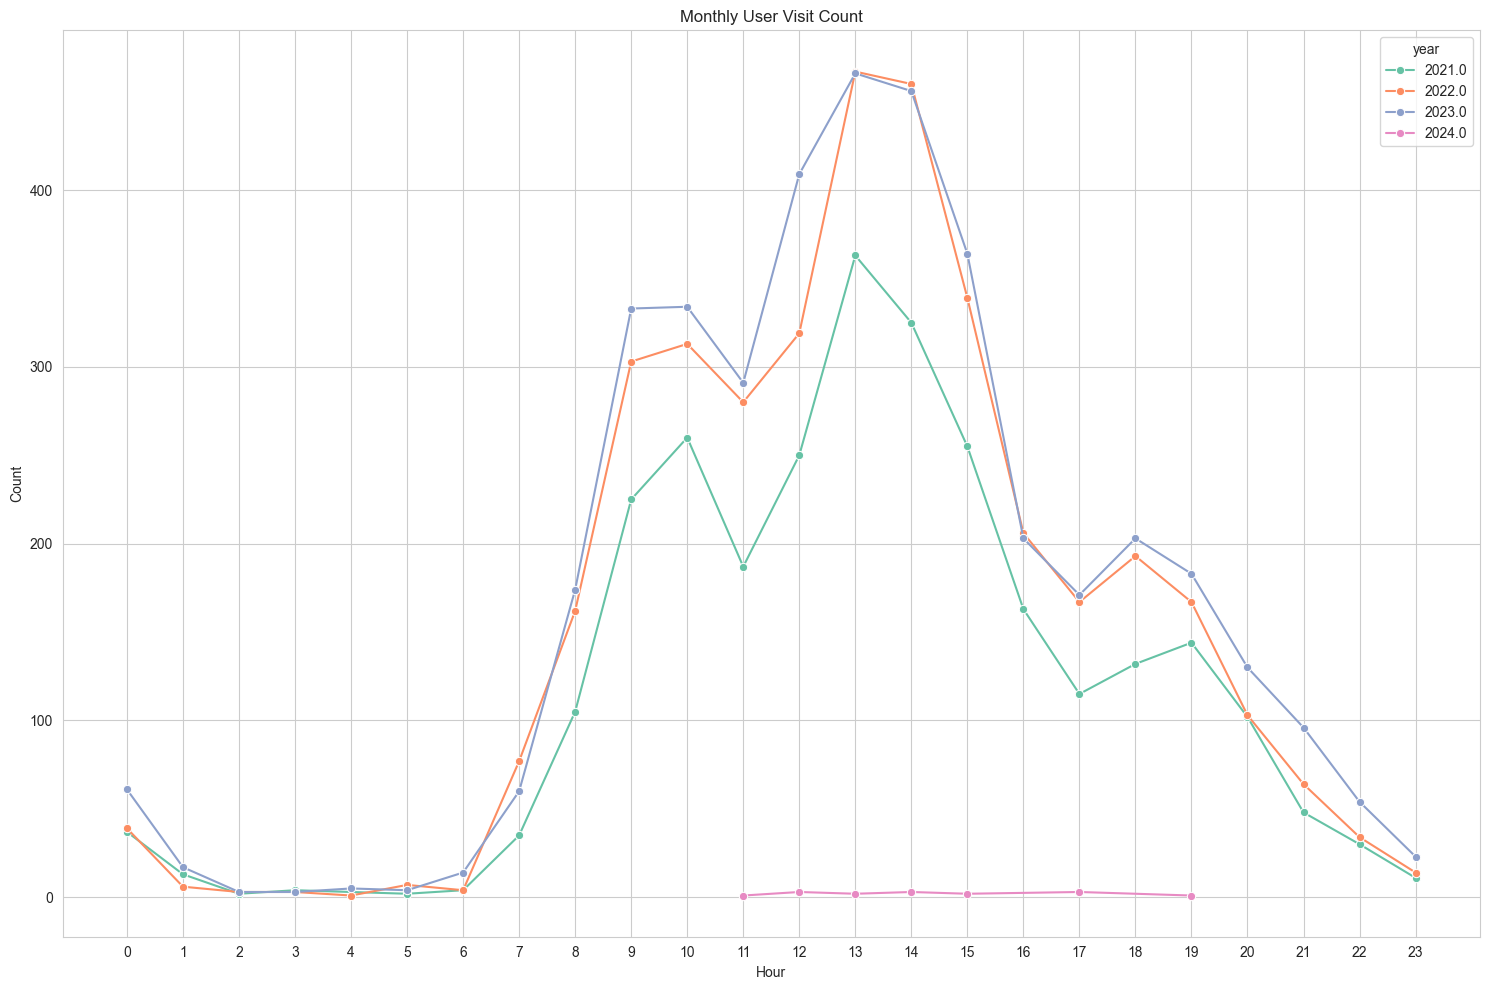

In [42]:
month_groupby_df = trial_visit_info_dropna.groupby(['year', 'hour']).size().reset_index(name='count')

plt.figure(figsize=(15, 10))
sns.set_style('whitegrid')
sns.lineplot(data=month_groupby_df, x='hour', y='count', hue='year', marker='o', palette='Set2')
plt.title('Monthly User Visit Count')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.xticks(month_groupby_df['hour'].unique())
plt.grid(True)
plt.tight_layout()
plt.show()